
# 🧠 BERT Embeddings Notebook - Learning Plan

We’ll use pretrained models from **Hugging Face** and **Google** via the **Transformers** library.

This notebook focuses on understanding **how contextual embeddings from BERT differ from classic static embeddings** like Word2Vec and GloVe.

---

## 📌 1. What is BERT?

**Goal:** Understand *why BERT changed NLP*.

BERT (Bidirectional Encoder Representations from Transformers) is a deep neural network based on the **Transformer encoder** architecture that learns language by reading text **in both directions at the same time**.

Unlike Word2Vec and GloVe, BERT does not learn a single vector per word.
Instead, it produces **context-dependent vectors** - the meaning of a word changes depending on the sentence it appears in.

BERT was pretrained on massive corpora (Wikipedia + BooksCorpus) using **Masked Language Modeling**, which allows it to learn deep relationships between words.

BERT can produce embeddings for:

* tokens
* words (after aggregation)
* sentences
* documents

👉 Key idea to emphasize:

> Word2Vec / GloVe → **one vector per word**
> BERT → **different vector per word per sentence**


---

## 🔄 2. BERT vs Word2Vec vs GloVe (conceptual table)

| Feature                | Word2Vec     | GloVe                | BERT                     |
| ---------------------- | ------------ | -------------------- | ------------------------ |
| Static vectors         | ✅            | ✅                    | ❌                        |
| Context aware          | ❌            | ❌                    | ✅                        |
| Training signal        | Local window | Global co-occurrence | Masked language modeling |
| OOV handling           | ❌            | ❌                    | ✅ (subwords)             |
| Sentence embeddings    | ❌            | ❌                    | ✅                        |
| Understands word order | ❌            | ❌                    | ✅                        |

---

### 🧠 Why this matters for learning

In the [previous notebook](https://github.com/Maxstef/data-loves-ml-for-people-course/blob/main/notebooks/4_1_nlp_intro/0_5_glove_fasttext_gensim_wikitext2.ipynb), we saw that:

* “apple ~ cat” or “car ~ banana” can look similar due to context noise
* models cannot understand **which meaning** of a word is used

In this notebook, we will see that BERT:

* understands **which meaning** of a word is used
* can compare **sentences**, not just words
* solves many limitations of Word2Vec and GloVe


---

## ⚙️ 3. Install & Imports

In [ ]:
# !pip install transformers torch sentence-transformers -q

In [ ]:
# download pre-trained Glove and word2vec embedding models
import gensim.downloader as api

glove = api.load("glove-wiki-gigaword-100")
# wv = api.load('word2vec-google-news-300')
# ft = api.load('fasttext-wiki-news-subwords-300')

## 🔤 4. BERT Tokenization Deep Dive

**Goal:** Show why BERT has no true OOV problem.

BERT does **not** work with full words like Word2Vec or GloVe.

Instead, it uses **WordPiece tokenization**:

* Words are broken into **subword units**
* These subwords come from a fixed vocabulary (~30k tokens)
* Unknown words are decomposed into known pieces

This is why BERT can handle words it has never seen before.

For example:

* `unhappiness` → split into meaningful parts: *un + happy + ness*
* `cybersecurity` → split into *cyber + security*

👉 This is the key reason BERT has **no real OOV issue**.


In [2]:
from transformers import BertTokenizer


bert_tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
print(bert_tokenizer.tokenize("unhappiness"))
print(bert_tokenizer.tokenize("cybersecurity"))

['un', '##ha', '##pp', '##iness']
['cyber', '##se', '##cu', '##rity']


**🧠 What to notice**

* `##` means “continuation of previous token”
* BERT understands morphology without FastText
* Any word can be represented using known subwords

This is a **major architectural advantage** over Word2Vec and GloVe.

### 🧩 From Tokens to Model Inputs

In the previous section, we only saw **how words are split** into subwords.

Here, we go one step further and see **how BERT prepares data to feed into the model**.

BERT does not take raw text or plain tokens.
It requires a **structured input** made of:

* **Token IDs**
* **Attention mask**
* **Token type IDs**

These tensors are what the model actually consumes.

In [3]:
text = "The quick brown fox jumps over the lazy dog."

bert_inputs = bert_tokenizer(text, return_tensors='pt')

print("Token IDs:", bert_inputs['input_ids'])

attention_mask = bert_inputs['attention_mask']
print("Attention Mask:", attention_mask)

token_type_ids = bert_inputs['token_type_ids']
print("Token Type IDs:", token_type_ids)

tokens = bert_tokenizer.convert_ids_to_tokens(bert_inputs['input_ids'][0])
print("Tokens:", tokens)


Token IDs: tensor([[  101,  1996,  4248,  2829,  4419, 14523,  2058,  1996, 13971,  3899,
          1012,   102]])
Attention Mask: tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])
Token Type IDs: tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])
Tokens: ['[CLS]', 'the', 'quick', 'brown', 'fox', 'jumps', 'over', 'the', 'lazy', 'dog', '.', '[SEP]']


### 🔍 What each part means

**Tokens**

```
['[CLS]', 'the', 'quick', 'brown', 'fox', ..., 'dog', '.', '[SEP]']
```

* `[CLS]` → special start token (used for sentence representation)
* `[SEP]` → special end/separator token

---

**Token IDs (`input_ids`)**

* Each token is converted to a number from BERT’s vocabulary
* This is what the embedding layer looks up

---

**Attention Mask**

* `1` → real token
* `0` → padding (if sentence was shorter than max length)
* Tells BERT what to pay attention to

---

**Token Type IDs**

* Used when **two sentences** are provided (sentence A vs B)
* All zeros here because we passed only one sentence

---

### 🧠 Key difference from the previous section

| Previous section                | This section                                 |
| ------------------------------- | -------------------------------------------- |
| Only showed how words are split | Shows full model-ready representation        |
| Pure tokenization               | Tokenization + numerical encoding + metadata |
| Conceptual view of WordPiece    | Practical view of BERT model input           |

👉 This is the exact structure passed into the BERT encoder.


In [4]:
text = ("The quick brown fox jumps over the dog",
        "A fast fox leaped across a lazy animal")

bert_inputs = bert_tokenizer(text[0], text[1], return_tensors='pt')

token_type_ids = bert_inputs['token_type_ids']
print("Token Type IDs:", token_type_ids)

tokens = bert_tokenizer.convert_ids_to_tokens(bert_inputs['input_ids'][0])
print(tokens)

Token Type IDs: tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1]])
['[CLS]', 'the', 'quick', 'brown', 'fox', 'jumps', 'over', 'the', 'dog', '[SEP]', 'a', 'fast', 'fox', 'leaped', 'across', 'a', 'lazy', 'animal', '[SEP]']


## 🧮 5. Extracting BERT Token Embeddings

In this section, we move from **tokenization** to actual **contextual embeddings** produced by BERT.

Unlike Word2Vec or GloVe, which assign a **single fixed vector per word**, BERT generates a **different vector for each token depending on its context in the sentence**.

We load a pretrained model from **Hugging Face** using the **Transformers** library.

Then we pass tokenized input through the model to obtain:

* **last_hidden_state** → contextual embedding for every token
* shape: `(batch_size, sequence_length, hidden_size)`

For BERT-base:

* hidden size = **768 dimensions**
* each token is represented as a **768-dimensional vector**


In [5]:
from transformers import BertTokenizer, BertModel
import torch

# Loading the pre-trained model and tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')

# Define text
text = "The quick brown fox jumps over the lazy dog."

# Tokenize text
inputs = tokenizer(text, return_tensors='pt')

# get embeddings
with torch.no_grad():
    outputs = model(**inputs)

# get last hidden state (embedding)
last_hidden_states = outputs.last_hidden_state

# shape of last hidden state
print("The shape of the last hidden state (embeddings):", last_hidden_states.shape)

# Output embeddings for each token along with their dimension
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
for token, embedding in zip(tokens, last_hidden_states[0]):
    print(f"Token: {token}, embedding shape: {embedding.shape}, Embedding (first 5 components): {embedding[:5]}...")

The shape of the last hidden state (embeddings): torch.Size([1, 12, 768])
Token: [CLS], embedding shape: torch.Size([768]), Embedding (first 5 components): tensor([-0.3608,  0.2271, -0.3030, -0.1880,  0.0475])...
Token: the, embedding shape: torch.Size([768]), Embedding (first 5 components): tensor([-0.3276, -0.3762, -0.5044,  0.0098,  0.9037])...
Token: quick, embedding shape: torch.Size([768]), Embedding (first 5 components): tensor([-0.4000, -0.4212,  0.4903,  0.0033,  0.4567])...
Token: brown, embedding shape: torch.Size([768]), Embedding (first 5 components): tensor([ 0.1209, -0.2728,  0.5550, -0.1874,  0.7759])...
Token: fox, embedding shape: torch.Size([768]), Embedding (first 5 components): tensor([ 0.0323, -0.2305, -0.1756, -0.1121,  0.5692])...
Token: jumps, embedding shape: torch.Size([768]), Embedding (first 5 components): tensor([ 0.2432, -0.0648,  0.3022,  0.2046,  0.7072])...
Token: over, embedding shape: torch.Size([768]), Embedding (first 5 components): tensor([-0.3485

---

### 🔍 What this output means

For the sentence:

> `"The quick brown fox jumps over the lazy dog"`

we get:

```
torch.Size([1, 12, 768])
```

This means:

* `1` → one sentence (batch size)
* `12` → number of tokens (including `[CLS]` and `[SEP]`)
* `768` → embedding size per token


## 🧩 6. Same Word, Different Embedding (Context Matters)

One of BERT’s biggest advantages over Word2Vec and GloVe is **contextual embeddings**.

The **same word** can have **different vectors** depending on the sentence.

We demonstrate this with the word **“bank”**:

```python
sent1 = "I went to the bank to deposit money."
sent2 = "The river bank was full of trees."
```

We will:

* tokenize both sentences
* extract BERT embeddings
* take the vector for **"bank"**
* compare them with cosine similarity

---

**🧠 Key idea**

> "bank" (finance) ≠ "bank" (river side)

BERT produces **different vectors** because it understands context.

Static embeddings from Word2Vec and GloVe cannot do this - they always return **one fixed vector per word**.

---

**✅ What we expect**

| Sentence      | Meaning               | Similarity |
| ------------- | --------------------- | ---------- |
| deposit money | financial institution |            |
| river bank    | geography             | **low**    |

This small experiment clearly shows **why BERT changed NLP**.


In [6]:
import torch
from transformers import BertTokenizer, BertModel
from sklearn.metrics.pairwise import cosine_similarity

# Load model + tokenizer
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
model = BertModel.from_pretrained("bert-base-uncased")

model.eval();

/opt/miniconda3/envs/mlpeople7/lib/python3.11/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [7]:
# Define sentences
sent1 = "I went to the bank to deposit money."
sent2 = "The river bank was full of trees."

In [27]:
# Function to extract word embedding
def get_word_embedding(sentence, target_word):
    inputs = tokenizer(sentence, return_tensors="pt")

    with torch.no_grad():
        outputs = model(**inputs)

    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    embeddings = outputs.last_hidden_state[0]

    # tokenize the target word the same way BERT does
    target_tokens = tokenizer.tokenize(target_word)

    # search for matching token sequence
    for i in range(len(tokens) - len(target_tokens) + 1):
        if tokens[i:i+len(target_tokens)] == target_tokens:
            # average subword embeddings
            return embeddings[i:i+len(target_tokens)].mean(dim=0).unsqueeze(0)

    return None

In [28]:
# Extract embeddings
emb1 = get_word_embedding(sent1, "bank")
emb2 = get_word_embedding(sent2, "bank")

In [29]:
# Compare similarity
similarity = cosine_similarity(emb1, emb2)[0][0]
print("Cosine similarity (bank vs bank):", similarity)

Cosine similarity (bank vs bank): 0.49230397


With GloVe, a word has one vector only.

> GloVe has no idea about sentence context.

In [30]:
glove_vec = glove["bank"].reshape(1, -1)

sim_glove = cosine_similarity(glove_vec, glove_vec)[0][0]
print("GloVe similarity (bank vs bank):", sim_glove)

GloVe similarity (bank vs bank): 1.0


### 📊 Visual proof - PCA / t-SNE of **“bank”** in multiple contexts

We’ll plot BERT embeddings in 2D to **see** how context changes meaning.

Idea:

* take several sentences where **“bank”** means *finance*
* several where **“bank”** means *river side*
* add a few clearly **finance** and **geography** words
* project all vectors to 2D with PCA / t-SNE

If BERT truly understands context, the points will form **two clusters**.


In [31]:
# define sentences
finance_sents = [
    "I went to the bank to deposit money.",
    "The bank approved my loan yesterday.",
    "She works at a large investment bank.",
]

geo_sents = [
    "The river bank was covered with grass.",
    "We sat on the bank and watched the water.",
    "Trees grow along the bank of the river.",
]

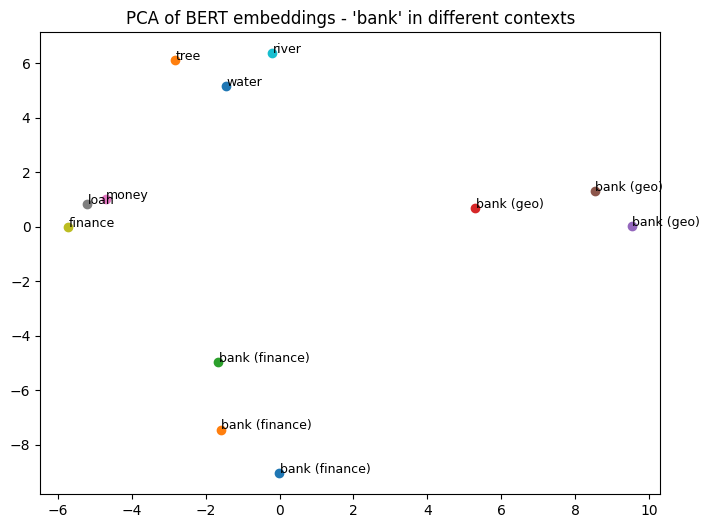

In [46]:
# imports
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Collect embeddings
points = []
labels = []

# bank in finance context
for s in finance_sents:
    emb = get_word_embedding(s, "bank")
    if emb is not None:
        points.append(emb.squeeze(0).numpy())
        labels.append("bank (finance)")

# bank in geography context
for s in geo_sents:
    emb = get_word_embedding(s, "bank")
    if emb is not None:
        points.append(emb.squeeze(0).numpy())
        labels.append("bank (geo)")

# reference words
ref_words = ["money", "loan", "finance", "river", "water", "tree"]

for w in ref_words:
    emb = get_word_embedding(f"This is about {w} and its bank.", w)
    if emb is not None:
        points.append(emb.squeeze(0).numpy())
        labels.append(w)

# convert to matrix
points = np.array(points)

# PCA projection
pca = PCA(n_components=2)
reduced = pca.fit_transform(points)

# plot
plt.figure(figsize=(8,6))
for (x, y), label in zip(reduced, labels):
    plt.scatter(x, y)
    plt.text(x + 0.01, y + 0.01, label, fontsize=9)

plt.title("PCA of BERT embeddings - 'bank' in different contexts")
plt.show()

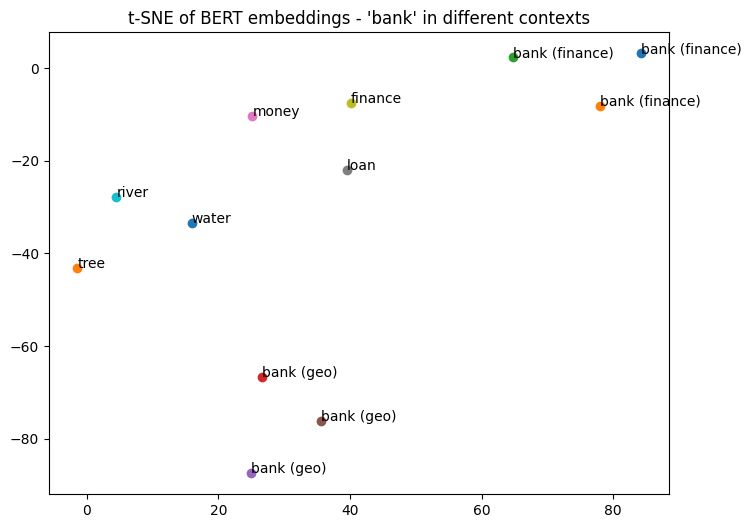

In [49]:
# TSNE projection
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, perplexity=5, random_state=42)
reduced_tsne = tsne.fit_transform(points)

plt.figure(figsize=(8,6))
for (x, y), label in zip(reduced_tsne, labels):
    plt.scatter(x, y)
    plt.text(x+0.01, y+0.01, label)

plt.title("t-SNE of BERT embeddings - 'bank' in different contexts")
plt.show()

* “bank (finance)” points cluster near money / loan / finance
* “bank (geo)” points cluster near river / water / tree
* Same word → two different regions of vector space

## 🧠 7. Word Embedding vs Sentence Embedding in BERT

BERT produces **token-level embeddings**, but we can derive **sentence-level representations** in multiple ways.

Each method captures meaning differently:

| Method        | Meaning                         | Typical use                |
| ------------- | ------------------------------- | -------------------------- |
| Token vector  | Contextual word embedding       | word analysis              |
| Mean pooling  | Average of all token embeddings | general sentence embedding |
| `[CLS]` token | special sentence summary token  | classification             |
| Sentence-BERT | fine-tuned sentence encoder     | similarity search          |

**🔍 Key idea**

* Word2Vec / GloVe → word-level only
* BERT → can produce **both word and sentence embeddings**


In [50]:
sentence = "The quick brown fox jumps over the lazy dog."
inputs = tokenizer(sentence, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)

last_hidden = outputs.last_hidden_state

### 🧠 1. Token embeddings (word-level)

Each token has its own vector:

In [51]:
token_embeddings = last_hidden[0]
print(token_embeddings.shape)  # (seq_len, 768)

torch.Size([12, 768])


👉 used for:

* word meaning in context
* NER (Named-Entity Recognition), POS (Part of Speech) tagging

### 🧠 2. Mean pooling (sentence embedding)

Simple and strong baseline:

In [52]:
mean_embedding = last_hidden.mean(dim=1)
print(mean_embedding.shape)  # (1, 768)

torch.Size([1, 768])


👉 intuition:

> “average meaning of all words”

### 🧠 3. [CLS] token embedding

BERT uses first token as sentence summary:

In [53]:
cls_embedding = last_hidden[0][0]
print(cls_embedding.shape)  # (768,)

torch.Size([768])


👉 used for:

* classification tasks
* sentiment analysis

### 🚀 4. Sentence-BERT (best for similarity)

Sentence-BERT improves BERT by:

* training specifically for **sentence similarity**
* producing **stable semantic embeddings**
* outperforming raw `[CLS]` embeddings

👉 used in:

* semantic search
* clustering
* document similarity


## 📦 8. Sentence Embeddings with Sentence-BERT

Sentence-BERT is a modified version of BERT designed specifically for **sentence-level similarity tasks**.

Unlike vanilla BERT:

* it is trained with **contrastive learning**
* outputs **direct sentence embeddings**
* works extremely well for semantic similarity


In [55]:
from sentence_transformers import SentenceTransformer

# Load Sentence-BERT
sbert_model = SentenceTransformer("all-MiniLM-L6-v2")

/opt/miniconda3/envs/mlpeople7/lib/python3.11/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [62]:
# Encode sentences
sentences = [
    "I went to the bank to deposit money.",
    "The river bank was full of trees.",
]

embeddings = sbert_model.encode(sentences)

embeddings.shape

(2, 384)

In [63]:
# Cosine similarity
from sklearn.metrics.pairwise import cosine_similarity

sim = cosine_similarity([embeddings[0]], [embeddings[1]])
print("SBERT similarity:", sim[0][0])

SBERT similarity: 0.31720668


**🧠 Key takeaway**

* SBERT gives **ready-to-use sentence vectors**
* no pooling needed
* best performance for similarity tasks

## 📏 9. Text Similarity Practice

We now test semantic similarity on multiple sentence pairs.

In [83]:
pairs = [
    ("I deposited money at the bank", "I went to the bank to withdraw cash"),
    ("The river bank is beautiful", "We sat near the flowing water and looked at river"),
    ("I went to the bank to withdraw cash", "I went to the river bank to enjoy the sunset."),
    ("She loves programming in Python", "She enjoys coding in Java"),
]

# Function for SBERT similarity
def sbert_sim(a, b):
    emb = sbert_model.encode([a, b])
    return cosine_similarity([emb[0]], [emb[1]])[0][0]

In [84]:
# Run similarity
for a, b in pairs:
    print("\nA:", a)
    print("B:", b)
    print("Similarity:", sbert_sim(a, b))


A: I deposited money at the bank
B: I went to the bank to withdraw cash
Similarity: 0.74576664

A: The river bank is beautiful
B: We sat near the flowing water and looked at river
Similarity: 0.51774114

A: I went to the bank to withdraw cash
B: I went to the river bank to enjoy the sunset.
Similarity: 0.36396265

A: She loves programming in Python
B: She enjoys coding in Java
Similarity: 0.71596175


## 🧪 10. Compare BERT vs GloVe vs SBERT

Now we build a **fair comparison across all models**.

In [85]:
# BERT CLS
def bert_cls(sentence):
    inputs = tokenizer(sentence, return_tensors="pt")
    with torch.no_grad():
        out = model(**inputs)
    return out.last_hidden_state[0][0].numpy()

# BERT mean pooling
def bert_mean(sentence):
    inputs = tokenizer(sentence, return_tensors="pt")
    with torch.no_grad():
        out = model(**inputs)
    return out.last_hidden_state.mean(dim=1)[0].numpy()

# GloVe mean pooling
def glove_mean(sentence):
    vecs = [glove[w] for w in sentence.split() if w in glove]
    return np.mean(vecs, axis=0)

In [92]:
def cosine(a, b):
    return cosine_similarity([a], [b])[0][0]

def print_results(sent1, sent2):
    print("BERT CLS     :", cosine(bert_cls(sent1), bert_cls(sent2)))
    print("BERT Mean    :", cosine(bert_mean(sent1), bert_mean(sent2)))
    print("GloVe        :", cosine(glove_mean(sent1), glove_mean(sent2)))
    print("Sentence-BERT:", cosine(sbert_model.encode([sent1])[0],
                               sbert_model.encode([sent2])[0]))

print_results("I went to the bank to deposit money", "The river bank was full of trees")

BERT CLS     : 0.8938744
BERT Mean    : 0.6004766
GloVe        : 0.85580623
Sentence-BERT: 0.332201


In [93]:
print_results("She loves programming in Python", "She enjoys coding in Java")

BERT CLS     : 0.9824982
BERT Mean    : 0.9082073
GloVe        : 0.7555685
Sentence-BERT: 0.71596175


In [96]:
print_results("What is the mean value?", "What do you mean?")

BERT CLS     : 0.9525979
BERT Mean    : 0.6744019
GloVe        : 0.7696797
Sentence-BERT: 0.16410801


* Word2Vec / GloVe → static averaging (weak sentence meaning)
* BERT CLS → general-purpose but not optimized
* BERT mean pooling → better but still unsupervised
* Sentence-BERT → best for semantic similarity

## 🌀 11. PCA / t-SNE Visualization of BERT Sentence Embeddings

We now visualize how sentences are organized in vector space using BERT embeddings.

Goal:

> Sentences with similar meaning should naturally cluster together.


In [102]:
# Example sentences clustered by semantic groups
sentences = [
    # finance
    "I deposited money at the bank",
    "The bank approved my loan",
    "She works in investment banking",

    # geography
    "We sat on the river bank",
    "The river flows near the city",
    "Trees grow along the water bank",

    # tech
    "I love programming in Python",
    "Java is widely used in software development",
    "Machine learning models require data",

    # animals
    "The cat is sleeping on the sofa",
    "The dog is running in the park",
    "A rabbit is eating grass"
]

labels = [
    "finance", "finance", "finance",
    "geo", "geo", "geo",
    "tech", "tech", "tech",
    "animal", "animal", "animal"
]

In [98]:
# Get sentence embeddings - use CLS embeddings (simple and consistent)
def bert_cls(sentence):
    inputs = tokenizer(sentence, return_tensors="pt")
    with torch.no_grad():
        outputs = model(**inputs)
    return outputs.last_hidden_state[0][0].numpy()

In [99]:
# Build embedding matrix
embeddings = np.array([bert_cls(s) for s in sentences])

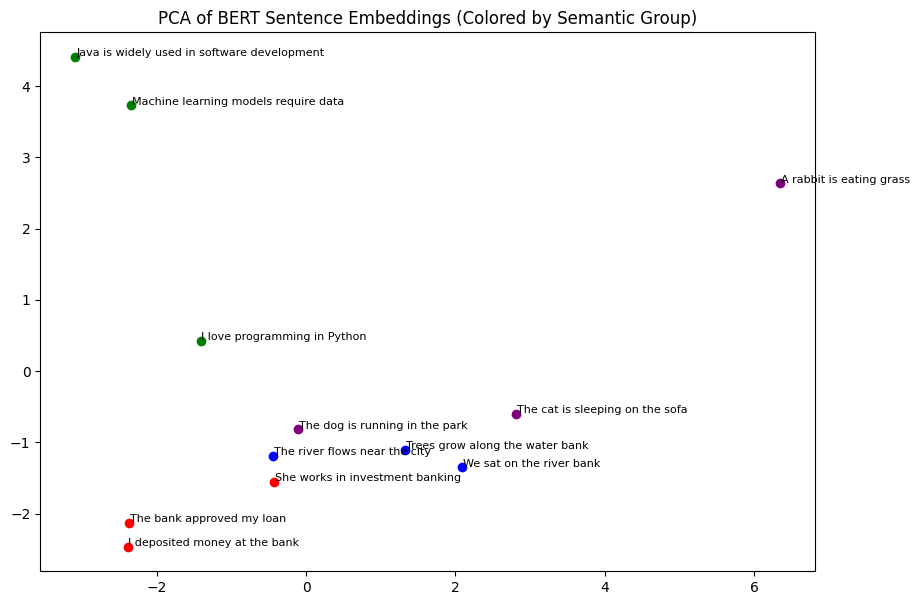

In [103]:
# PCA visualization
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)

color_map = {
    "finance": "red",
    "geo": "blue",
    "tech": "green",
    "animal": "purple"
}

plt.figure(figsize=(10,7))

for (x, y), label, text in zip(reduced, labels, sentences):
    plt.scatter(x, y, color=color_map[label])
    plt.text(x + 0.01, y + 0.01, text, fontsize=8)

plt.title("PCA of BERT Sentence Embeddings (Colored by Semantic Group)")
plt.show()

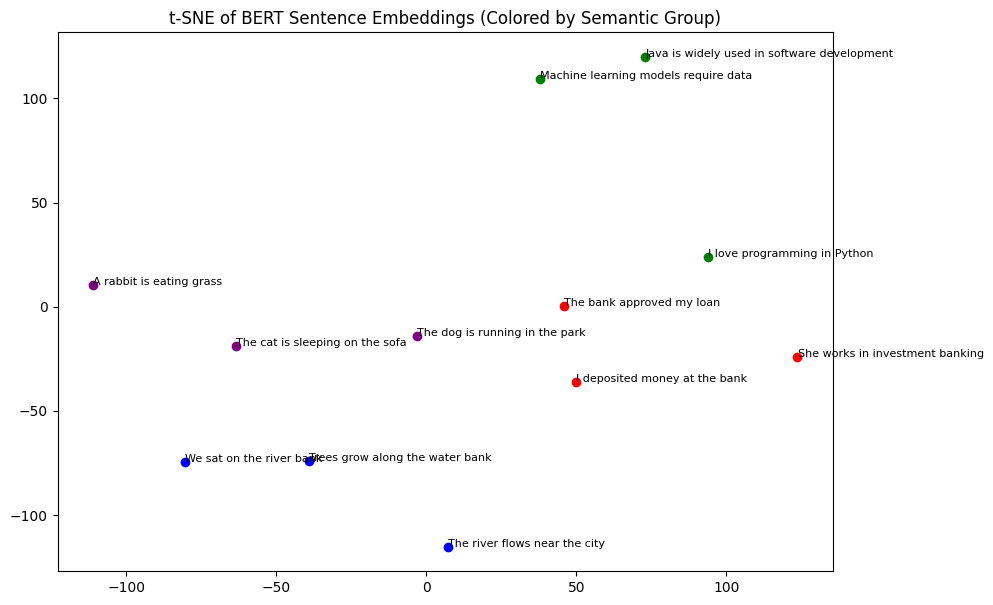

In [104]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=5, random_state=42)
reduced_tsne = tsne.fit_transform(embeddings)

plt.figure(figsize=(10,7))

for (x, y), label, text in zip(reduced_tsne, labels, sentences):
    plt.scatter(x, y, color=color_map[label])
    plt.text(x + 0.01, y + 0.01, text, fontsize=8)

plt.title("t-SNE of BERT Sentence Embeddings (Colored by Semantic Group)")
plt.show()

## 🔎 12. Semantic Search System

Semantic search retrieves text based on **meaning rather than exact keyword match**.

Instead of checking whether words overlap, we convert both the query and all sentences into vector embeddings and compare them using cosine similarity.

We use Sentence-BERT because it produces high-quality sentence vectors where semantically similar texts are close in embedding space.

👉 In practice:

* query → embedding vector
* corpus → precomputed embedding vectors
* similarity → cosine distance
* result → most semantically similar sentences

This allows the system to match paraphrases and related concepts even when they share no exact words.


In [105]:
# Dataset (knowledge base)
corpus = [
    "I deposited money at the bank",
    "The bank approved my loan",
    "She works in investment banking",

    "We sat on the river bank",
    "The river flows near the city",
    "Trees grow along the water bank",

    "I love programming in Python",
    "Java is widely used in software development",
    "Machine learning models require data",

    "The cat is sleeping on the sofa",
    "The dog is running in the park",
    "A rabbit is eating grass"
]

In [106]:
# Encode corpus
from sentence_transformers import SentenceTransformer
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

model_sbert = SentenceTransformer("all-MiniLM-L6-v2")

corpus_embeddings = model_sbert.encode(corpus)

/opt/miniconda3/envs/mlpeople7/lib/python3.11/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [107]:
# Search function
def search(query, top_k=3):
    query_emb = model_sbert.encode([query])

    scores = cosine_similarity(query_emb, corpus_embeddings)[0]

    top_idx = scores.argsort()[::-1][:top_k]

    results = [(corpus[i], scores[i]) for i in top_idx]
    return results

In [108]:
# try it
query = "money loan from bank"

results = search(query)

print("Query:", query)
print("\nTop matches:\n")

for text, score in results:
    print(f"{score:.4f} -> {text}")

Query: money loan from bank

Top matches:

0.7098 -> The bank approved my loan
0.4812 -> I deposited money at the bank
0.3615 -> We sat on the river bank


In [109]:
print(search("river and water environment"))
print(search("I like coding and programming"))
print(search("small animals in the house"))

[('The river flows near the city', 0.61141586), ('Trees grow along the water bank', 0.535685), ('We sat on the river bank', 0.50981426)]
[('I love programming in Python', 0.65846485), ('Java is widely used in software development', 0.3542976), ('She works in investment banking', 0.1568403)]
[('A rabbit is eating grass', 0.19643947), ('The dog is running in the park', 0.17235796), ('Trees grow along the water bank', 0.09679371)]


## 🧪 13. Next Sentence Prediction (Similarity-based practice)

**🧠 Idea**

We approximate “next sentence prediction” by checking:

> Does sentence B logically follow sentence A?

We do this using embeddings + cosine similarity with Sentence-BERT.


In [110]:
# Sentence pairs
pairs = [
    ("I went to the bank to withdraw money.", "The clerk processed my transaction."),
    ("I went to the bank to withdraw money.", "The river bank was full of trees."),
    ("She opened her laptop and started coding.", "She wrote a Python function."),
    ("She opened her laptop and started coding.", "The dog is playing outside."),
]

In [111]:
# Scoring function
from sklearn.metrics.pairwise import cosine_similarity

def similarity(a, b):
    emb = model_sbert.encode([a, b])
    return cosine_similarity([emb[0]], [emb[1]])[0][0]

In [112]:
# Evaluate pairs
for a, b in pairs:
    score = similarity(a, b)

    print("\nA:", a)
    print("B:", b)
    print("Similarity:", round(score, 4))


A: I went to the bank to withdraw money.
B: The clerk processed my transaction.
Similarity: 0.4899

A: I went to the bank to withdraw money.
B: The river bank was full of trees.
Similarity: 0.252

A: She opened her laptop and started coding.
B: She wrote a Python function.
Similarity: 0.5194

A: She opened her laptop and started coding.
B: The dog is playing outside.
Similarity: 0.0576


* ✔ logical continuation → high similarity (e.g., bank → transaction)
* ❌ unrelated sentence → low similarity (e.g., coding → dog)
* ⚠ ambiguous cases → medium similarity

this can be easily turned into:
* “Correct next sentence classifier”
    * label: correct / incorrect continuation
    * threshold-based decision
    * or ranking multiple candidates

## 🚀 14. Final Takeaways - Why BERT and What It Changes

BERT uses **768-dimensional embeddings**, while models like Word2Vec and GloVe typically use ~100–300 dimensions.

However, the key difference is not the size - it’s what the vector represents.

---

**🧠 Core idea**

* Word2Vec / GloVe → **one static vector per word**
* BERT → **different vector per word depending on context**

---

**⚖️ Why BERT uses higher dimensions**

* encodes context + syntax + meaning
* distinguishes word senses (bank 🏦 vs river 🌊)
* represents full sentence-aware token states

---

**🚀 Final insight**

* Word2Vec / GloVe → fast, simple, static semantics
* BERT → contextual understanding of language

👉 Modern NLP prefers BERT-style models because **meaning depends on context, not just words**
